<a href="https://colab.research.google.com/github/shalini2006official/KMeans_clustering/blob/main/Mall_customer_using_k_Means_clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual_Income_(k$),0
Spending_Score,0


In [ ]:
from scipy.stats import zscore
numeric = df.select_dtypes(include='number')
z_scores = np.abs(zscore(numeric))
outlier = df[(z_scores>2.5).any (axis=1)]
outlier

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
from scipy.stats.mstats import winsorize
numeric_cols=df.select_dtypes(include= np.number).columns
for col in numeric_cols:
  df[col] = winsorize(df[col],limits=[0,0.1])
print(df)

     CustomerID   Genre  Age  Annual_Income_(k$)  Spending_Score
0             1    Male   19                  15              39
1             2    Male   21                  15              81
2             3  Female   20                  16               6
3             4  Female   23                  16              77
4             5  Female   31                  17              40
..          ...     ...  ...                 ...             ...
195         180  Female   35                  93              79
196         180  Female   45                  93              28
197         180    Male   32                  93              74
198         180    Male   32                  93              18
199         180    Male   30                  93              83

[200 rows x 5 columns]


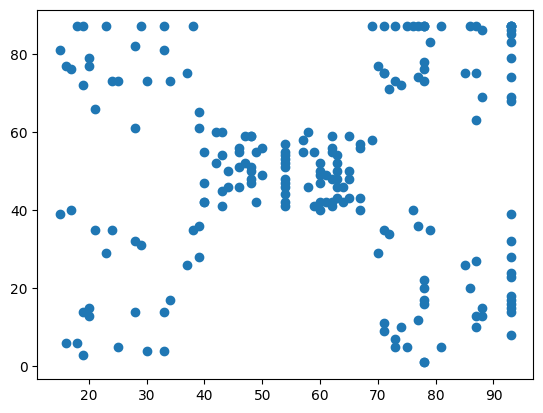

In [ ]:
x=df['Annual_Income_(k$)']
y=df['Spending_Score']
plt.scatter(x,y)

<BarContainer object of 200 artists>

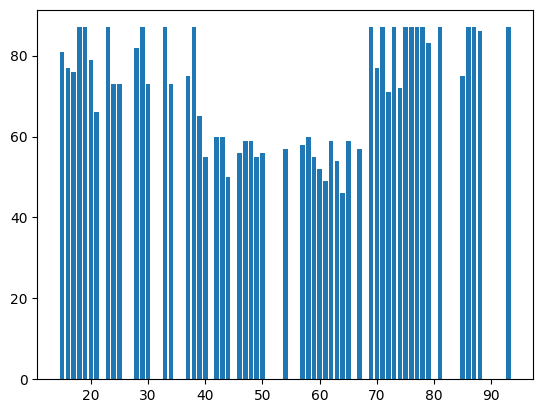

In [ ]:
x=df['Annual_Income_(k$)']
y=df['Spending_Score']
plt.bar(x,y)

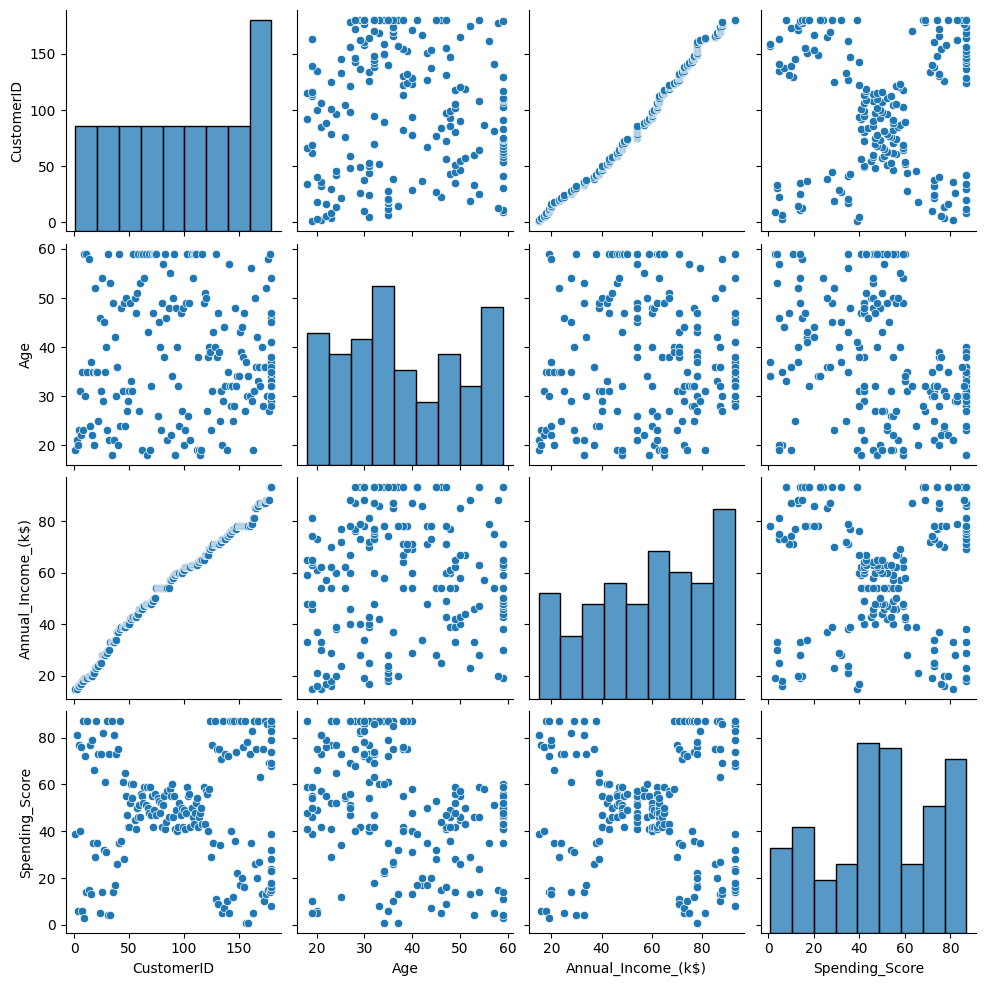

In [ ]:
sns.pairplot(df)

In [ ]:
q = df.iloc[:,3:].values# first : represents all rows
#3: represents fron 3 rd column
q

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40],
       [17, 76],
       [18,  6],
       [18, 87],
       [19,  3],
       [19, 72],
       [19, 14],
       [19, 87],
       [20, 15],
       [20, 77],
       [20, 13],
       [20, 79],
       [21, 35],
       [21, 66],
       [23, 29],
       [23, 87],
       [24, 35],
       [24, 73],
       [25,  5],
       [25, 73],
       [28, 14],
       [28, 82],
       [28, 32],
       [28, 61],
       [29, 31],
       [29, 87],
       [30,  4],
       [30, 73],
       [33,  4],
       [33, 87],
       [33, 14],
       [33, 81],
       [34, 17],
       [34, 73],
       [37, 26],
       [37, 75],
       [38, 35],
       [38, 87],
       [39, 36],
       [39, 61],
       [39, 28],
       [39, 65],
       [40, 55],
       [40, 47],
       [40, 42],
       [40, 42],
       [42, 52],
       [42, 60],
       [43, 54],
       [43, 60],
       [43, 45],
       [43, 41],
       [44, 50],
       [44, 46],
       [46, 51

In [ ]:
from sklearn.cluster import KMeans

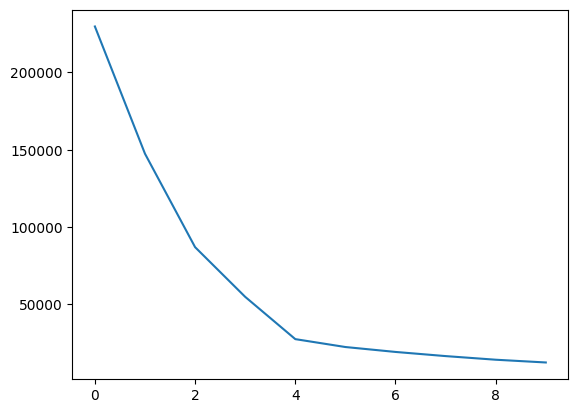

In [ ]:
inertiaval=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=0)
  kmeans.fit(q)
  inertiaval.append(kmeans.inertia_)
plt.plot(inertiaval)

In [ ]:
kmeans=KMeans(n_clusters=5,init=('k-means++'),random_state=42)
y_kmeans=kmeans.fit_predict(q)

In [ ]:
kmeans.inertia_

27624.17847636725

In [ ]:
kmeans.labels_

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

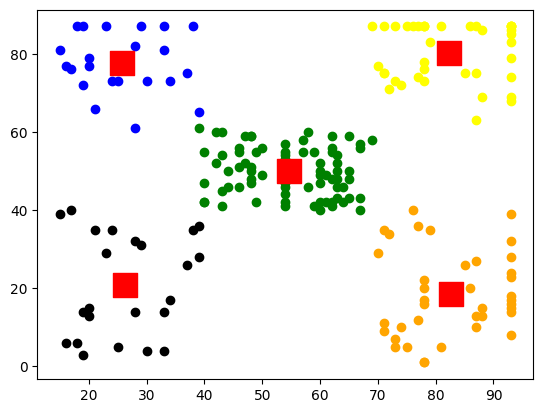

In [ ]:
plt.scatter(q[y_kmeans==0,0],q[y_kmeans==0,1],color='green',label='cluster1')
plt.scatter(q[y_kmeans==1,0],q[y_kmeans==1,1],color='yellow',label='cluster2')
plt.scatter(q[y_kmeans==2,0],q[y_kmeans==2,1],color='blue',label='cluster3')
plt.scatter(q[y_kmeans==3,0],q[y_kmeans==3,1],color='orange',label='cluster4')
plt.scatter(q[y_kmeans==4,0],q[y_kmeans==4,1],color='black',label='cluster5')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],color='red',label='centroids',s=300,marker=',')#in marker any val can be given